# 07 — News and Sentiment

## What you'll learn
- Where a ticker's headlines come from — Yahoo's own news list plus two public RSS feeds — with **no API key**.
- How to fetch and de-duplicate a news table with `stocklearn.news.get_news`.
- How **VADER** turns a headline into a sentiment score (compound, positive/negative/neutral labels).
- How to aggregate many headlines into a single *verdict* and chart the counts.
- Where rule-based sentiment breaks: sarcasm, negation scope, and domain jargon.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from stocklearn.news import get_news
from stocklearn.sentiment import analyze_text, score_headlines, aggregate_sentiment

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

ticker = "AAPL"          # <-- swap this one variable to study another company
limit = 15               # how many headlines to keep


## One variable to change

Everything below is driven by the `ticker` variable in the setup cell. Change it once
(e.g. to `"MSFT"` or `"TSLA"`) and re-run the notebook to study a different company.

### Where do the headlines come from?

`get_news` combines **two best-effort sources**:

1. **Yahoo's own news list** for the ticker (via `yfinance`). These carry titles,
   publishers, links and publish times.
2. **Public RSS feeds** — the Yahoo Finance headline feed, and a Google News search
   feed as a backup. RSS is a simple XML format that news sites publish for
   syndication; no signup or key required.

Because both sources often carry the *same* story, `get_news` de-duplicates in two ways:
first by **link**, then by a **normalised title** (lower-cased, whitespace collapsed, and
with Google's `" - Publisher"` suffix stripped). That second step catches the same story
arriving under different URLs. Finally it sorts newest-first by `published`.

Some feeds are messier than others: a small number of entries can be missing a `title`
or a `link`. `get_news` drops those rather than showing you half a row.


In [2]:
news = get_news(ticker, limit=limit)
print(f"{len(news)} headlines for {ticker}")
news[["title", "publisher", "published", "source"]]


15 headlines for AAPL


,title,publisher,published,source
0,Apple Inc. $AAPL Stock Sold by Denver PWM LLC - MarketBeat,MarketBeat,2026-10-03 07:12:22+00:00,google-news
1,Apple Inc. $AAPL Stock Purchased by Bedel Financial Consulting Inc. - Market...,MarketBeat,2026-10-03 07:08:22+00:00,google-news
2,"Mag 7 Voices: Huang Defends AI Spending, Pichai Ramps Up Gemini, Nadella Cal...",Stocktwits,2026-10-03 02:01:35+00:00,yfinance
3,AAPL Stock Heads For Worst Single-Day Fall In Over A Year — Wall Street Warn...,Stocktwits,2026-10-02 23:11:15+00:00,google-news
4,Apple Says Some AT&T iPhone 18 Pro Max Users Must Replace Phones After Servi...,Yahoo! Finance: AAPL News,2026-10-02 23:03:33+00:00,yahoo-rss
5,Apple Tightens macOS Full Disk Access,MT Newswires,2026-10-02 22:06:15+00:00,yfinance
6,Apple (AAPL) Exceeds Market Returns: Some Facts to Consider,Yahoo! Finance: AAPL News,2026-10-02 20:45:04+00:00,yahoo-rss
7,"Microsoft Entered the Smart Home Through Your Washing Machine, Not Your Phone",Yahoo! Finance: AAPL News,2026-10-02 20:18:01+00:00,yahoo-rss
8,Morgan Stanley Has Strong Verdict for Apple Stock Investors,GuruFocus.com,2026-10-02 20:03:07+00:00,yfinance
9,"Buy, Hold, or Fade Tesla Stock After Its Q3 Delivery Beat?",Zacks,2026-10-02 19:26:00+00:00,yfinance


### Reading the table

- **title** — the headline text, the only thing we score for sentiment.
- **publisher** — who wrote it (note that Google News often re-publishes others' work).
- **published** — a timezone-aware UTC timestamp; newest rows come first.
- **source** — which of our two feeds delivered the row (`yfinance`, `yahoo-rss`, or
  `google-news`). Useful for debugging: if `source` is only `google-news`, Yahoo's own
  list was probably throttled at that moment.

If the table is empty, nothing is broken: RSS and Yahoo are best-effort, and the rest of
the notebook still runs (the sentiment verdict simply becomes `neutral`).


## Scoring headlines with VADER

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a *lexicon + rules*
scorer. It has a dictionary where words carry a valence (how positive/negative), plus
rules for punctuation, capitalisation, degree modifiers ("very good"), and negation
("not good"). For any text it returns four numbers:

- `neg`, `neu`, `pos` — proportions that are negative, neutral, positive;
- `compound` — a single number in **[-1, +1]** summarising the whole text.

For headlines we mainly use `compound`. By VADER's own convention, `>= +0.05` is
"positive", `<= -0.05` is "negative", and everything in between is "neutral".


In [3]:
scored = score_headlines(news["title"].tolist())
scored


,title,compound,label
0,Apple Inc. $AAPL Stock Sold by Denver PWM LLC - MarketBeat,0.0000,neutral
1,Apple Inc. $AAPL Stock Purchased by Bedel Financial Consulting Inc. - Market...,0.0000,neutral
2,"Mag 7 Voices: Huang Defends AI Spending, Pichai Ramps Up Gemini, Nadella Cal...",0.0000,neutral
3,AAPL Stock Heads For Worst Single-Day Fall In Over A Year — Wall Street Warn...,-0.6705,negative
4,Apple Says Some AT&T iPhone 18 Pro Max Users Must Replace Phones After Servi...,0.0000,neutral
5,Apple Tightens macOS Full Disk Access,0.0000,neutral
6,Apple (AAPL) Exceeds Market Returns: Some Facts to Consider,0.0000,neutral
7,"Microsoft Entered the Smart Home Through Your Washing Machine, Not Your Phone",0.4019,positive
8,Morgan Stanley Has Strong Verdict for Apple Stock Investors,0.5994,positive
9,"Buy, Hold, or Fade Tesla Stock After Its Q3 Delivery Beat?",0.0000,neutral


### From many headlines to one verdict

`aggregate_sentiment` scores every title and summarises the list:

- `mean_compound` — the average of all compound scores;
- `positive` / `negative` / `neutral` — how many titles fell in each bucket;
- `verdict` — `"bullish"` if the mean is `>= +0.05`, `"bearish"` if `<= -0.05`, else
  `"neutral"`.

Averaging is a blunt instrument, but it is a transparent one — and being explicit about
the rule is the point of this notebook.


In [4]:
agg = aggregate_sentiment(news["title"].tolist())
print(f"Mean compound : {agg['mean_compound']:+.4f}")
print(f"Verdict       : {agg['verdict']}")
print(f"Positive      : {agg['positive']}")
print(f"Negative      : {agg['negative']}")
print(f"Neutral       : {agg['neutral']}")


Mean compound : +0.0576
Verdict       : positive
Positive      : 5
Negative      : 3
Neutral       : 7


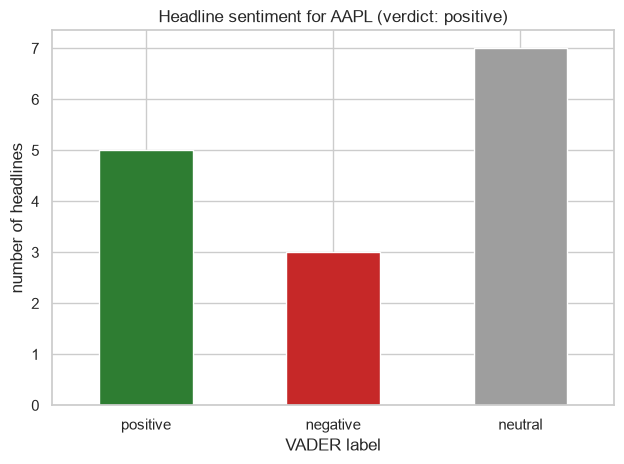

In [5]:
counts = pd.Series(
    {"positive": agg["positive"], "negative": agg["negative"], "neutral": agg["neutral"]}
)
colors = {"positive": "#2e7d32", "negative": "#c62828", "neutral": "#9e9e9e"}

ax = counts.plot(kind="bar", color=[colors[c] for c in counts.index], rot=0)
ax.set_title(f"Headline sentiment for {ticker} (verdict: {agg['verdict']})")
ax.set_xlabel("VADER label")
ax.set_ylabel("number of headlines")
plt.tight_layout()
plt.show()


## Where the scorer gets it wrong — hand-typed examples

Live headlines are a moving target, so let's feed the scorer four headlines we control
and watch exactly what it does. Run the next cell and read the scores carefully: the
point is to build intuition for the **failure modes**.


In [6]:
examples = [
    ("clearly bullish", "Apple stock jumps as iPhone sales beat expectations and profits climb"),
    ("clearly bearish", "Apple stock falls as iPhone sales miss expectations and analysts cut targets"),
    ("plainly neutral", "Apple announces its annual developer conference will be held in June"),
    ("tricky: sarcasm", "Great, another analyst downgrade for Apple - just what investors needed"),
    ("tricky: jargon/negation", "Apple shares plunge after regulators fine the company and warn of a slowdown"),
]

for kind, text in examples:
    compound = analyze_text(text)["compound"]
    print(f"{compound:+.4f}  [{kind:26s}] {text}")


+0.4404  [clearly bullish           ] Apple stock jumps as iPhone sales beat expectations and profits climb
-0.4019  [clearly bearish           ] Apple stock falls as iPhone sales miss expectations and analysts cut targets
+0.0000  [plainly neutral           ] Apple announces its annual developer conference will be held in June
+0.6249  [tricky: sarcasm           ] Great, another analyst downgrade for Apple - just what investors needed
+0.3818  [tricky: jargon/negation   ] Apple shares plunge after regulators fine the company and warn of a slowdown


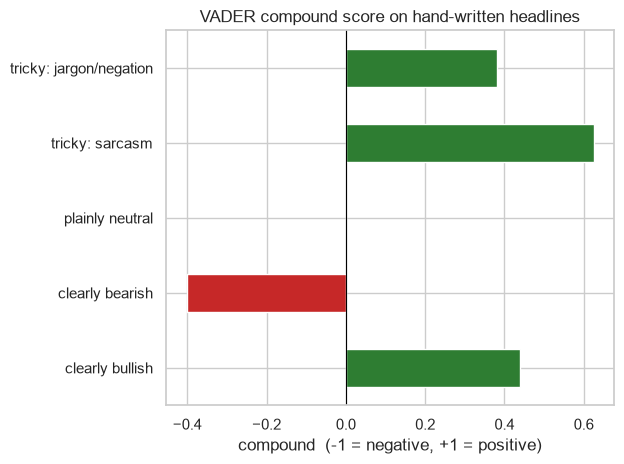

In [7]:
demo = pd.DataFrame(
    {"kind": [k for k, _ in examples],
     "compound": [analyze_text(t)["compound"] for _, t in examples]}
)

ax = demo.plot(kind="barh", x="kind", y="compound", legend=False,
               color=["#2e7d32" if v >= 0.05 else "#c62828" if v <= -0.05 else "#9e9e9e"
                      for v in demo["compound"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("VADER compound score on hand-written headlines")
ax.set_xlabel("compound  (-1 = negative, +1 = positive)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## The honest limitations

VADER is a **lexicon + rules** scorer: deterministic, instant, no API key, no training
data, no model download. Those are real advantages. They also come with real blind spots:

- **Sarcasm and irony.** "Great, another downgrade — just what investors needed"
  contains the positive words *great* and *needed*, so it scores clearly **positive**,
  even though the writer means exactly the opposite.
- **Negation scope.** VADER handles a simple "not good", but the *scope* of a negation
  across a long headline is easy to get wrong.
- **Domain jargon.** In finance, *"fine"* (a penalty) is bad news, but VADER's lexicon
  rates it as a positive word — so a headline about regulators fining a company can
  score positive. Likewise *"beat"* and *"miss"* are not handled the way a trader means
  them.
- **Positive wording around negative facts.** "Shares fall less than feared" reads as a
  win to a human but its words are mostly negative.

**Never treat this score as a forecast.** It measures the tone of a bag of words, not
whether a stock will rise. Even in the aggregate, an empty headline list honestly
returns a **neutral** verdict with zero counts — absence of news is not a bullish or
bearish signal, and the code says so rather than guessing.


In [8]:
# Absence of news is neutral, not an error:
print(aggregate_sentiment([]))


{'mean_compound': 0.0, 'positive': 0, 'negative': 0, 'neutral': 0, 'verdict': 'neutral'}


## Recap / try this

- Headlines come from Yahoo's news list plus public RSS feeds; `get_news` merges,
  de-duplicates (by link, then normalised title) and sorts them newest-first.
- VADER maps each title to a `compound` score in [-1, +1]; the aggregate turns a batch
  of headlines into a transparent bull/bear/neutral verdict.
- It is a **lexicon + rules** tool — deterministic and key-free, but blind to sarcasm,
  jargon and context. It is a tone reading, never a forecast.

**Try this:**
1. Swap `ticker` to a company with heavy, opinionated coverage (e.g. `"TSLA"`) and compare
   the counts and verdict with AAPL.
2. Add your own obviously-sarcastic headline to `examples` and see whether VADER falls for it.
3. Raise `limit` to 50 and check whether the verdict changes — does more news make the
   signal steadier or noisier?
4. Break the `aggregate_sentiment` rule by hand: are a few very negative headlines enough
   to drag the *mean* below -0.05 when most titles are neutral?
